<a href="https://colab.research.google.com/github/JakeOh/202605_BD57/blob/main/lab_python/da13_apt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colab에서 한글 폰트 사용하기

## Step 1. Colab 런타임(리눅스 가상머신)에 한글 폰트 설치

In [1]:
# Jupyter Notebook 코드 셀에서 리눅스 명령어를 실행
!sudo apt install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (6,500 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and direc

*   `sudo apt install -y fonts-nanum`
    *   sudo: 관리자 권한으로 실행.
    *   apt: 리눅스 패키지(프로그램) 관리자. 설치, 삭제 등.
    *   install: 설치
    *   -y 옵션: 설치 중에 사용자에게 물어보는 질문들에 대해서 yes라고 답.
    *   fonts-name: 폰트 종류
*   `sudo fc-cache -fv`
    *   리눅스에서 새로운 폰트를 설치한 후, OS에서 설치된 폰트를 바로 인식할 수 있도록 폰트 캐시를 강제로 업데이트.
    *   font config cache(폰트 설정 캐시)
    *   -f 옵셔: 강제 적용.
*   `rm ~/.cache/matplotlib -rf`
    *   rm: remove. 파일 또는 디렉토리를 삭제.
    *   ~/.cache/matplotlib: 삭제할 폴더 경로.
    *   -rf 옵션: recursive, force. 모든 하위 폴더들을 강제로(파일 존재 여부에 상관 없이) 삭제.

## Step 2. Colab 런타임을 재시작

~/.cache 디렉토리 아래에 matplotlib 디렉토리가 새로 생성됨.

Colab 런타임에 새로 설치된 폰트가 matplotlib에 등록.

## Step 3. matplotlib.pyplot 모듈에서 설치한 한글 폰트를 사용할 수 있도록 설정

In [1]:
import matplotlib.pyplot as plt

plt.rc('font', family='NanumBarunGothic')

## 테스트

In [2]:
import pandas as pd
import seaborn as sns

In [3]:
df = pd.DataFrame(data={
    '시군구': ['서초구', '강남구', '송파구'],
    '가격': [9_000, 10_000, 9_500],
})
df

,시군구,가격
0,서초구,9000
1,강남구,10000
2,송파구,9500


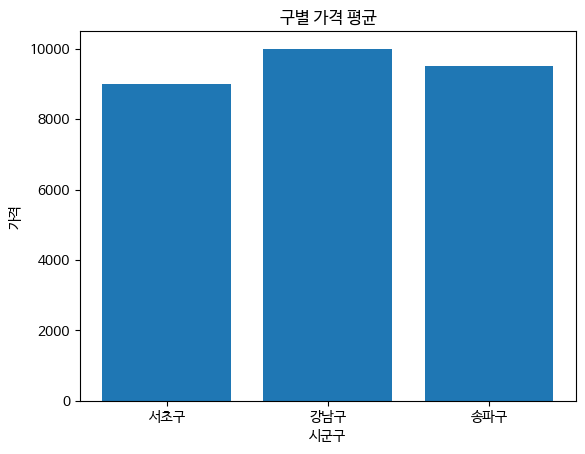

In [5]:
plt.bar(x=df['시군구'], height=df['가격'])
plt.xlabel('시군구')
plt.ylabel('가격')
plt.title('구별 가격 평균')
plt.show()

# 아파트 실거래가 분석

*   [apt_202504.csv](https://github.com/JakeOh/202605_BD57/raw/refs/heads/main/datasets/apt_202504.csv) 파일을 읽고 DataFrame 생성
    *   첫 15줄은 파일 설명 문서 -> skip
    *   encoding 파라미터 설정(한글 인코딩: euc-kr)
    *   '가격' 컬럼에는 숫자 자릿수를 구분하는 comma가 사용되고 있음(예: 10,000)
        *   '가격' 컬럼은 숫자 타입이어야 함!
    *   일부 컬럼에서는 '-' 문자열이 NA(Not Available, 값이 없음)의 의미로 사용되고 있음.
        *   '-'는 NA로 대체.
*   데이터 프레임 파악
    *   info, head, tail, describe, dtypes, ...
*   '시군구' 컬럼의 값을 이용해서, province 파생 변수(광역시도)를 만듦.
    *   '인천광역시 부평구 부평동' -> '인천광역시'
    *   '충청남도 천안시 서북구' -> '충청남도'
*   '시군구' 컬럼의 값을 이용해서, county 파생 변수(시/군/구)를 만듦.
    *   '인천광역시 부평구 부평동' -> '부평구'
    *   '충청남도 천안시 서북구' -> '천안시'
*   '계약년월' 컬럼의 값을 이용해서, year(계약년도), month(계약월) 파생 변수 만듦.
    *   202504 -> 2025(year), 4(month)
*   서울특별시 아파트들의 구별 아파트 가격의 개수, 평균, 최솟값, 최댓값
*   광역시도별 아파트 가격 개수, 평균, 최솟값, 최댓값
*   면적이  $84 m^2$  이상  $100 m^2$  미만의 서울특별시 아파트들 중에서, 구별 아파트 가격 개수, 평균, 최솟값, 최댓값
*   면적이 $84 m^2$ 이상 $100 m^2$ 미만의 아파트들 중에서, 광역시도별 아파트 가격 개수, 평균, 최솟값, 최댓값
    *   결과를 평균의 내림차순으로 정렬해서 출력
    *   결과를 최댓값의 내림차순으로 정렬해서 출력
    *   결과를 최솟값의 오름차순으로 정렬해서 출력
